In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK4_WORK_ROOT = (
    PROJECT_ROOT / "task4"
)

TASK4_REPO_ROOT = (
    REPO_ROOT / "task4"
)

DATA_ROOT = (
    PROJECT_ROOT / "datasets"
)

CHECKPOINT_PATH = (
    TASK4_WORK_ROOT
    / "checkpoints/gcsc_best.pt"
)

CIFAR10_SPLIT_PATH = (
    TASK4_REPO_ROOT
    / "splits/"
    "cifar10_train_val_seed6304.json"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)

Device: cuda
GPU: Tesla T4
Checkpoint: /content/drive/MyDrive/ATML/PA1/task4/checkpoints/gcsc_best.pt


In [9]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml

from common.seed import set_seed

from task4.data.cifar10 import (
    build_cifar10_datasets,
    build_cifar10_loaders,
)

from task4.data.make_splits import (
    load_cifar10_split,
)

from task4.evaluation.classification import (
    evaluate_closed_set,
)

from task4.methods.gcsc import (
    build_gcsc_model,
)

from task4.models.resnet_cifar import (
    count_trainable_parameters,
)

from task4.train import (
    train_closed_set_model,
)


SEED = 6304

set_seed(SEED)

with (
    TASK4_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK4_REPO_ROOT
    / "configs/gcsc.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config[
        "method"
    ]["name"],
)

print(
    "RandAugment enabled:",
    method_config[
        "method"
    ]["randaugment"],
)

print(
    "RandAugment operations:",
    method_config[
        "augmentation"
    ]["number_of_operations"],
)

print(
    "RandAugment magnitude:",
    method_config[
        "augmentation"
    ]["magnitude"],
)

print(
    "CIFAR-100 allowed for selection:",
    base_config[
        "selection"
    ]["use_cifar100"],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: gcsc
RandAugment enabled: True
RandAugment operations: 2
RandAugment magnitude: 9
CIFAR-100 allowed for selection: False


In [10]:
cifar10_split = (
    load_cifar10_split(
        CIFAR10_SPLIT_PATH
    )
)

cifar10_datasets = (
    build_cifar10_datasets(
        data_root=DATA_ROOT,
        split=cifar10_split,
        use_randaugment=True,
        download=True,
    )
)

cifar10_loaders = (
    build_cifar10_loaders(
        datasets_by_split=(
            cifar10_datasets
        ),
        batch_size=base_config[
            "optimization"
        ]["batch_size"],
        number_of_workers=base_config[
            "optimization"
        ]["number_of_workers"],
        seed=SEED,
    )
)

print(
    "Training examples:",
    len(
        cifar10_datasets[
            "train"
        ]
    ),
)

print(
    "Validation examples:",
    len(
        cifar10_datasets[
            "validation"
        ]
    ),
)

print(
    "Known test examples:",
    len(
        cifar10_datasets[
            "test"
        ]
    ),
)

print(
    "Training batches:",
    len(
        cifar10_loaders[
            "train"
        ]
    ),
)

print(
    "RandAugment used for training:",
    True,
)

print(
    "Unknown dataset loaded:",
    False,
)

Training examples: 45000
Validation examples: 5000
Known test examples: 10000
Training batches: 352
RandAugment used for training: True
Unknown dataset loaded: False


In [11]:
set_seed(SEED)

model = build_gcsc_model().to(
    DEVICE
)

print(
    "Trainable parameters:",
    count_trainable_parameters(
        model
    ),
)

print(
    "Classifier outputs:",
    model.number_of_outputs,
)

print(
    "Checkpoint exists already:",
    CHECKPOINT_PATH.exists(),
)

Trainable parameters: 11173962
Classifier outputs: 10
Checkpoint exists already: True


In [12]:
training_result = (
    train_closed_set_model(
        method_name="gcsc",
        model=model,
        loaders=cifar10_loaders,
        checkpoint_path=(
            CHECKPOINT_PATH
        ),
        device=DEVICE,
        maximum_epochs=base_config[
            "optimization"
        ]["maximum_epochs"],
        learning_rate=base_config[
            "optimization"
        ]["learning_rate"],
        momentum=base_config[
            "optimization"
        ]["momentum"],
        weight_decay=base_config[
            "optimization"
        ]["weight_decay"],
        number_of_classes=10,
        use_mixed_precision=True,
    )
)

model = training_result[
    "model"
]

training_history = training_result[
    "history"
]

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK4_REPO_ROOT
    / "results/"
    "gcsc_training_history.csv"
)

training_history.to_csv(
    history_path,
    index=False,
)

print()
print(
    "Selected epoch:",
    selected_checkpoint[
        "epoch"
    ],
)

print(
    "Selected validation accuracy:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

gcsc epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 1: train loss=2.0423, train accuracy=0.2599, validation accuracy=0.3760, best=0.3760


gcsc epoch 2:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch 2: train loss=1.5129, train accuracy=0.4433, validation accuracy=0.5022, best=0.5022


gcsc epoch 3:   0%|          | 0/352 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    Exception ignored in: if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
self._shutdown_workers()AssertionError
:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
can only test a child process
    if w.is_alive():
  File "/usr/lib/

Epoch 99: train loss=0.0341, train accuracy=0.9895, validation accuracy=0.9586, best=0.9586


gcsc epoch 100:   0%|          | 0/352 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080><function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/tor

Epoch 100: train loss=0.0335, train accuracy=0.9896, validation accuracy=0.9584, best=0.9586

Selected epoch: 99
Selected validation accuracy: 0.9586
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/gcsc_training_history.csv


In [13]:
validation_metrics = (
    evaluate_closed_set(
        model=model,
        data_loader=(
            cifar10_loaders[
                "validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=10,
    )
)

test_metrics = (
    evaluate_closed_set(
        model=model,
        data_loader=(
            cifar10_loaders[
                "test"
            ]
        ),
        device=DEVICE,
        number_of_classes=10,
    )
)

closed_set_results = pd.DataFrame(
    [
        {
            "method": "gcsc",
            "split": "validation",
            "accuracy": (
                validation_metrics[
                    "accuracy"
                ]
            ),
            "macro_f1": (
                validation_metrics[
                    "macro_f1"
                ]
            ),
            "loss": (
                validation_metrics[
                    "loss"
                ]
            ),
            "number_of_samples": (
                validation_metrics[
                    "number_of_samples"
                ]
            ),
        },
        {
            "method": "gcsc",
            "split": "test",
            "accuracy": (
                test_metrics[
                    "accuracy"
                ]
            ),
            "macro_f1": (
                test_metrics[
                    "macro_f1"
                ]
            ),
            "loss": (
                test_metrics[
                    "loss"
                ]
            ),
            "number_of_samples": (
                test_metrics[
                    "number_of_samples"
                ]
            ),
        },
    ]
)

results_path = (
    TASK4_REPO_ROOT
    / "results/"
    "gcsc_closed_set_metrics.csv"
)

closed_set_results.to_csv(
    results_path,
    index=False,
)

print(
    closed_set_results.to_string(
        index=False
    )
)

print()
print(
    "Results saved to:",
    results_path,
)

method      split  accuracy  macro_f1     loss  number_of_samples
  gcsc validation    0.9586  0.958703 0.149937               5000
  gcsc       test    0.9509  0.950957 0.165076              10000

Results saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/gcsc_closed_set_metrics.csv


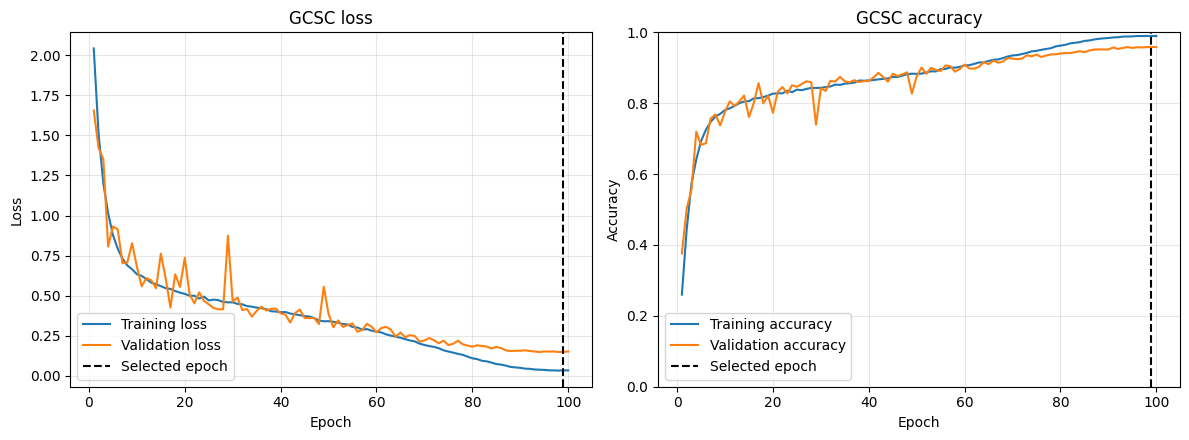

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/figures/gcsc_training_curves.png


In [14]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_loss"
    ],
    label="Training loss",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "validation_loss"
    ],
    label="Validation loss",
)

axes[0].axvline(
    selected_checkpoint[
        "epoch"
    ],
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("GCSC loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history[
        "training_accuracy"
    ],
    label="Training accuracy",
)

axes[1].plot(
    training_history["epoch"],
    training_history[
        "validation_accuracy"
    ],
    label="Validation accuracy",
)

axes[1].axvline(
    selected_checkpoint[
        "epoch"
    ],
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("GCSC accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK4_REPO_ROOT
    / "figures/"
    "gcsc_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [15]:
import numpy as np

from task4.extract_outputs import (
    extract_model_outputs,
)

from task4.scores.mls import (
    mls_unknownness,
)


CACHE_ROOT = (
    TASK4_WORK_ROOT / "cache"
)

CACHE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

gcsc_outputs = {}

for split_name in [
    "validation",
    "test",
]:
    extracted_outputs = (
        extract_model_outputs(
            model=model,
            data_loader=(
                cifar10_loaders[
                    split_name
                ]
            ),
            device=DEVICE,
            description=(
                f"GCSC {split_name}"
            ),
        )
    )

    output_path = (
        CACHE_ROOT
        / (
            f"gcsc_{split_name}_"
            "outputs.npz"
        )
    )

    np.savez_compressed(
        output_path,
        logits=(
            extracted_outputs[
                "logits"
            ]
        ),
        features=(
            extracted_outputs[
                "features"
            ]
        ),
        labels=(
            extracted_outputs[
                "labels"
            ]
        ),
        dataset_indices=(
            extracted_outputs[
                "dataset_indices"
            ]
        ),
    )

    gcsc_outputs[
        split_name
    ] = extracted_outputs

validation_mls = (
    mls_unknownness(
        torch.from_numpy(
            gcsc_outputs[
                "validation"
            ]["logits"]
        )
    )
    .numpy()
)

test_mls = (
    mls_unknownness(
        torch.from_numpy(
            gcsc_outputs[
                "test"
            ]["logits"]
        )
    )
    .numpy()
)

gcsc_mls_threshold = float(
    np.percentile(
        validation_mls,
        95,
    )
)

validation_acceptance = float(
    np.mean(
        validation_mls
        <= gcsc_mls_threshold
    )
)

test_acceptance = float(
    np.mean(
        test_mls
        <= gcsc_mls_threshold
    )
)

gcsc_known_score_summary = (
    pd.DataFrame(
        [
            {
                "model": "gcsc",
                "score": "mls",
                "threshold": (
                    gcsc_mls_threshold
                ),
                "validation_acceptance_rate": (
                    validation_acceptance
                ),
                "known_test_acceptance_rate": (
                    test_acceptance
                ),
                "known_test_rejection_rate": (
                    1.0
                    - test_acceptance
                ),
            }
        ]
    )
)

known_score_path = (
    TASK4_REPO_ROOT
    / "results/"
    "gcsc_known_score_summary.csv"
)

gcsc_known_score_summary.to_csv(
    known_score_path,
    index=False,
)

threshold_path = (
    TASK4_REPO_ROOT
    / "results/"
    "gcsc_mls_threshold.json"
)

with threshold_path.open(
    "w",
    encoding="utf-8",
) as threshold_file:
    json.dump(
        {
            "model": "gcsc",
            "score": "mls",
            "percentile": 95,
            "calibration_split": (
                "cifar10_validation"
            ),
            "threshold": (
                gcsc_mls_threshold
            ),
            "cifar100_used": False,
        },
        threshold_file,
        indent=2,
    )

print(
    gcsc_known_score_summary.to_string(
        index=False
    )
)

GCSC validation:   0%|          | 0/40 [00:00<?, ?it/s]

GCSC test:   0%|          | 0/79 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7aec580f9080>
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.13/multiprocessing/process.py", line 1

model score  threshold  validation_acceptance_rate  known_test_acceptance_rate  known_test_rejection_rate
 gcsc   mls  -6.411793                        0.95                      0.9472                     0.0528


In [16]:
gcsc_metadata = {
    "method": "gcsc",
    "seed": SEED,
    "initialization": "random",
    "randaugment": {
        "number_of_operations": 2,
        "magnitude": 9,
    },
    "selected_epoch": int(
        selected_checkpoint[
            "epoch"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "cifar10_validation": {
        "accuracy": float(
            validation_metrics[
                "accuracy"
            ]
        ),
        "macro_f1": float(
            validation_metrics[
                "macro_f1"
            ]
        ),
    },
    "cifar10_test": {
        "accuracy": float(
            test_metrics[
                "accuracy"
            ]
        ),
        "macro_f1": float(
            test_metrics[
                "macro_f1"
            ]
        ),
    },
    "mls_threshold": float(
        gcsc_mls_threshold
    ),
    "known_test_acceptance_rate": float(
        test_acceptance
    ),
    "checkpoint_filename": (
        CHECKPOINT_PATH.name
    ),
    "cifar100_used_for_training": False,
    "cifar100_used_for_selection": False,
    "cifar100_used_for_threshold": False,
}

metadata_path = (
    TASK4_REPO_ROOT
    / "results/gcsc_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        gcsc_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        gcsc_metadata,
        indent=2,
    )
)

{
  "method": "gcsc",
  "seed": 6304,
  "initialization": "random",
  "randaugment": {
    "number_of_operations": 2,
    "magnitude": 9
  },
  "selected_epoch": 99,
  "selection_score": 0.9586,
  "cifar10_validation": {
    "accuracy": 0.9586,
    "macro_f1": 0.9587026850433702
  },
  "cifar10_test": {
    "accuracy": 0.9509,
    "macro_f1": 0.9509568660773187
  },
  "mls_threshold": -6.411793231964111,
  "known_test_acceptance_rate": 0.9472,
  "checkpoint_filename": "gcsc_best.pt",
  "cifar100_used_for_training": false,
  "cifar100_used_for_selection": false,
  "cifar100_used_for_threshold": false
}
